In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score


In [196]:
df = pd.read_csv("loan_approval_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [198]:
df[df.isnull().any(axis=1)]

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
7,8.0,6426.0,3186.0,Salaried,47.0,Married,2.0,636.0,4.0,NaN,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,NaN,No
8,9.0,16423.0,NaN,Salaried,54.0,Married,1.0,729.0,0.0,0.59,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,993.0,19939.0,7993.0,Unemployed,NaN,Single,2.0,766.0,2.0,0.28,6680.0,47037.0,2848.0,24.0,Business,Semiurban,Graduate,Male,Government,Yes
994,NaN,2804.0,5542.0,Unemployed,NaN,Married,1.0,749.0,4.0,0.43,8250.0,34831.0,NaN,60.0,Business,Semiurban,Graduate,Female,Private,No
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No


## Handling Missing Values

In [199]:
impute_mean = SimpleImputer(missing_values= np.nan, strategy= 'mean')
impute_mode = SimpleImputer(missing_values= np.nan, strategy= 'most_frequent')

col_mean = df[['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio','Savings','Collateral_Value','Loan_Amount','Loan_Term']]
col_mode = df[['Employment_Status','Marital_Status', 'Loan_Purpose', 'Property_Area',	'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved']]

get_numerical = impute_mean.fit_transform(col_mean)
get_categorical = impute_mode.fit_transform(col_mode)

In [200]:
df2 = pd.DataFrame(columns=col_mean.columns, data=get_numerical)
df3 = pd.DataFrame(columns=col_mode.columns, data=get_categorical)
df_filled = pd.concat([df2, df3] , axis=1)
df_filled

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Employment_Status,Marital_Status,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Salaried,Married,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Salaried,Married,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Salaried,Single,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Salaried,Married,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Self-employed,Single,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Salaried,Married,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Self-employed,Married,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Contract,Single,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Unemployed,Single,Personal,Urban,Graduate,Male,Private,Yes


In [201]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Age                 1000 non-null   float64
 3   Dependents          1000 non-null   float64
 4   Credit_Score        1000 non-null   float64
 5   Existing_Loans      1000 non-null   float64
 6   DTI_Ratio           1000 non-null   float64
 7   Savings             1000 non-null   float64
 8   Collateral_Value    1000 non-null   float64
 9   Loan_Amount         1000 non-null   float64
 10  Loan_Term           1000 non-null   float64
 11  Employment_Status   1000 non-null   object 
 12  Marital_Status      1000 non-null   object 
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

## Feature Encoding


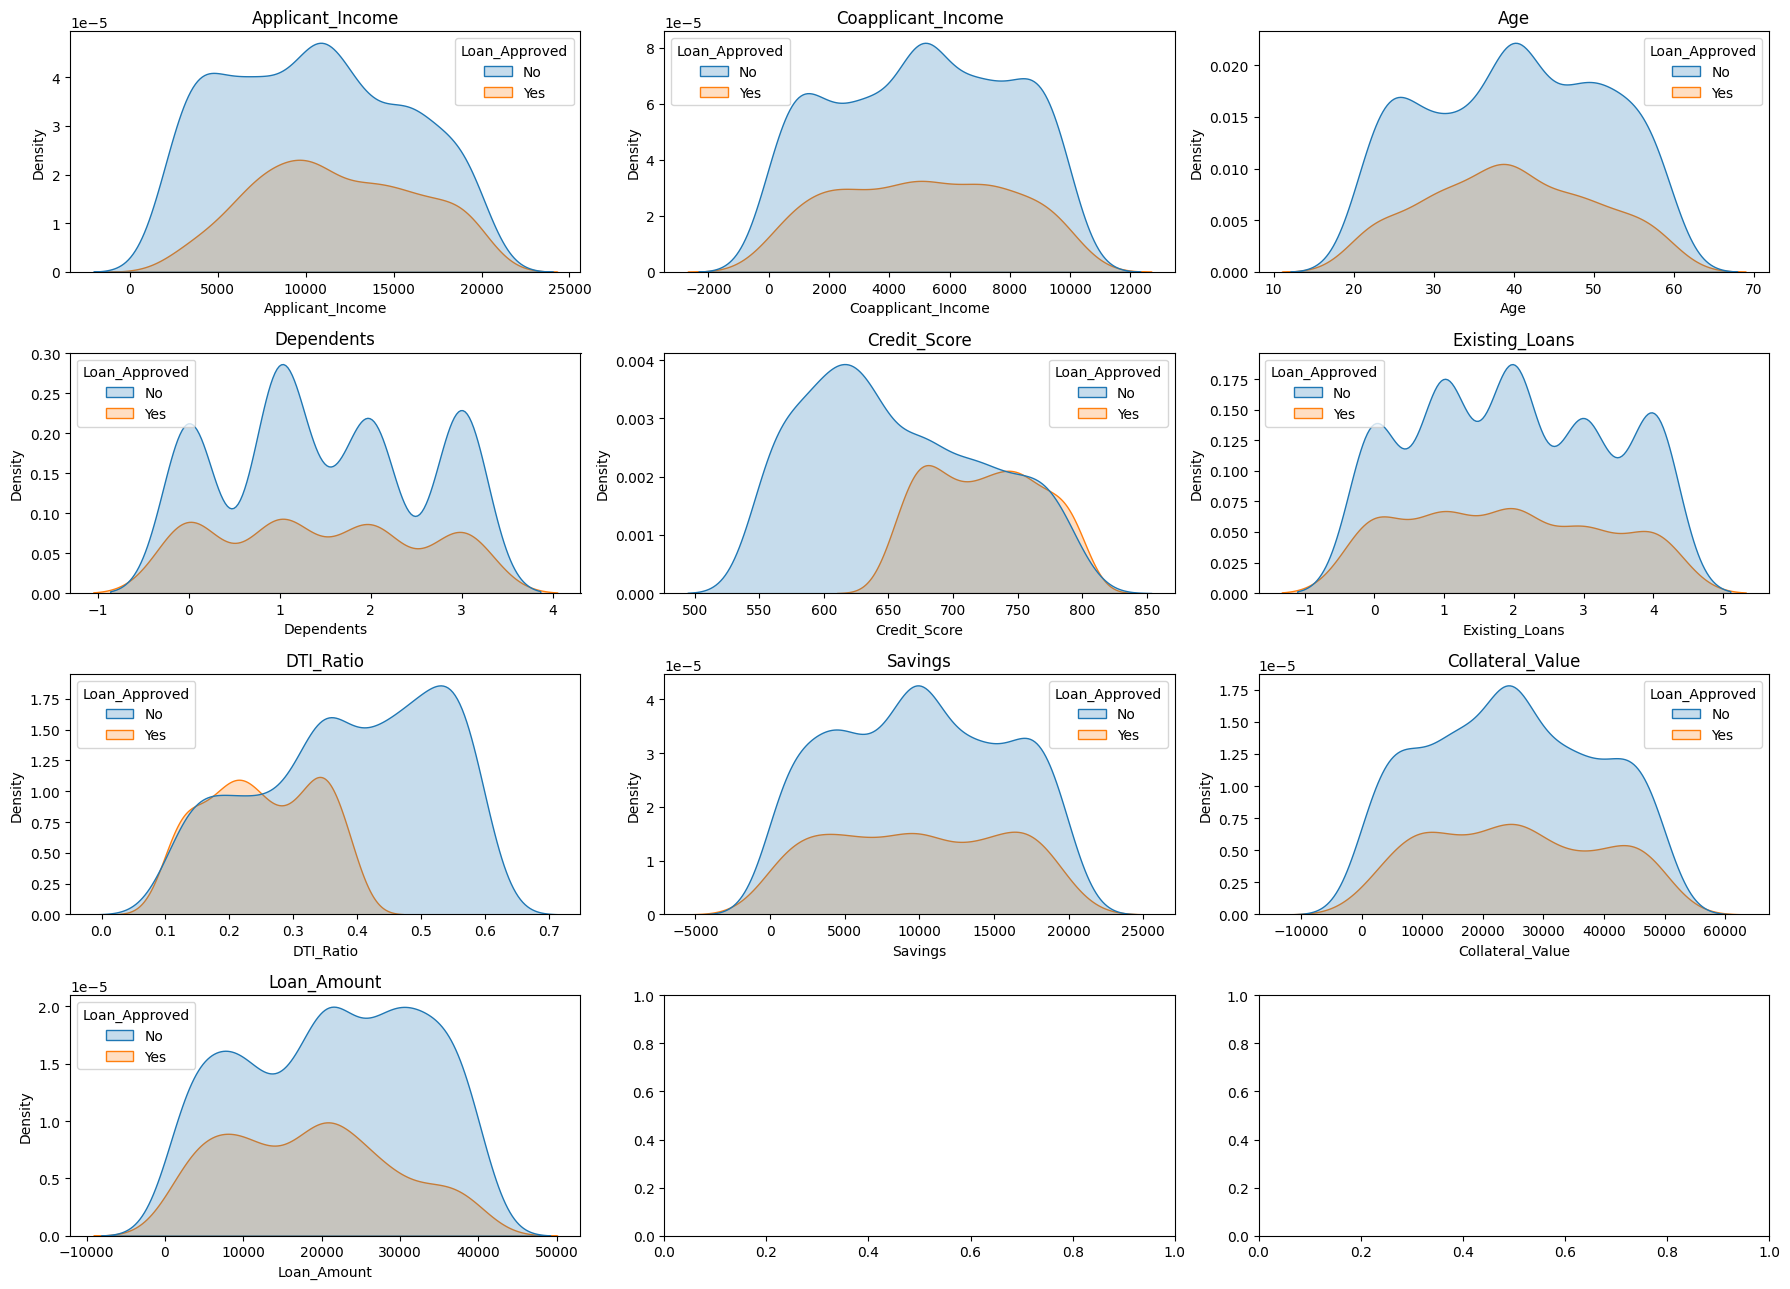

In [202]:
# Kde for Numerical

fig, axes = plt.subplots(nrows=4, ncols=3, figsize= (18,13))
axes = axes.flatten()

for i, col in enumerate(df_filled.columns[:10]):
    sns.kdeplot(data = df_filled, x = col, ax = axes[i], fill = True, hue='Loan_Approved')
    axes[i].set_title(col)

plt.tight_layout()

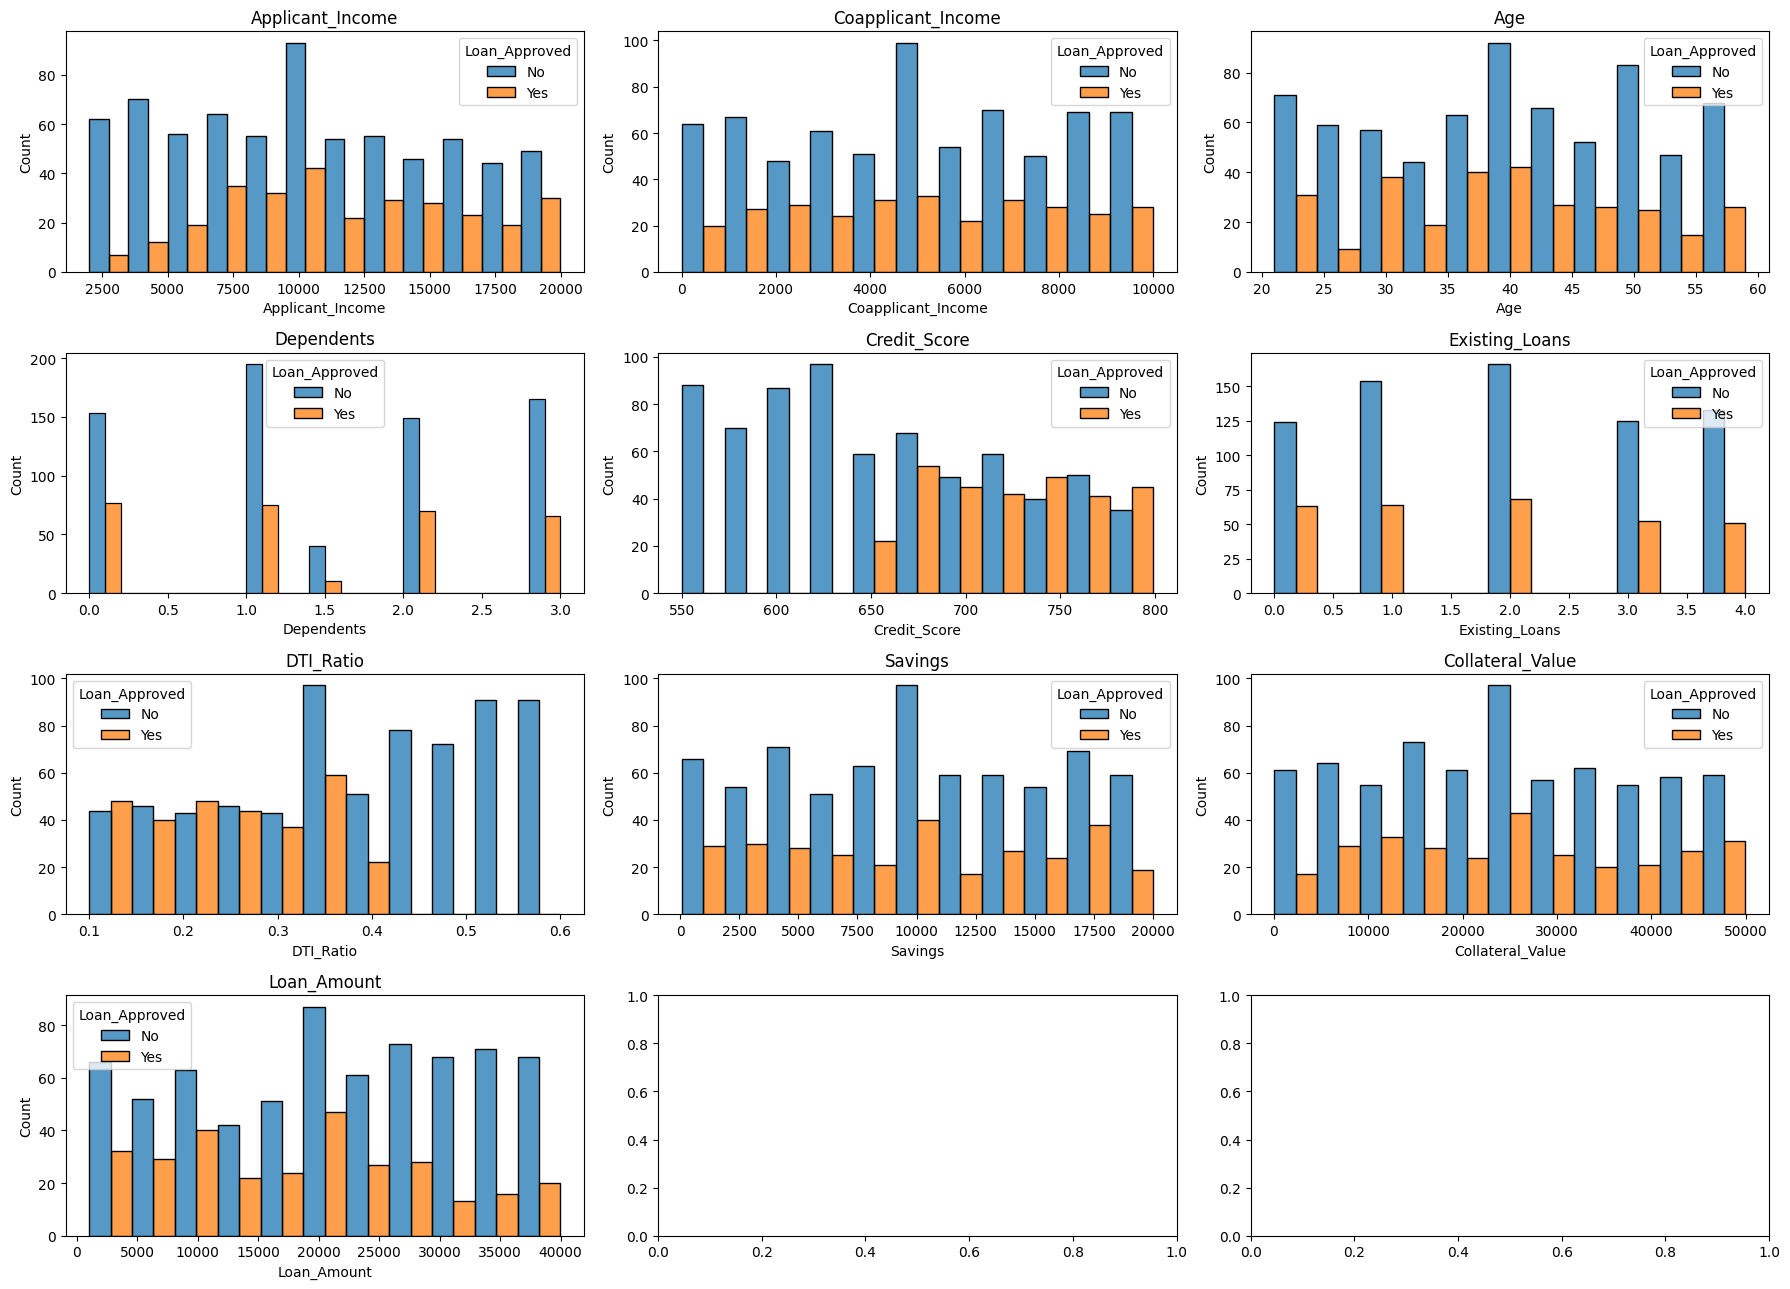

In [203]:
# Hist for Numerical

fig, axes = plt.subplots(nrows=4, ncols=3, figsize= (18,13))
axes = axes.flatten()

for i, col in enumerate(df_filled.columns[:10]):
    sns.histplot(data = df_filled, x = col, ax = axes[i], fill = True, hue='Loan_Approved', multiple='dodge')
    axes[i].set_title(col)

plt.tight_layout()

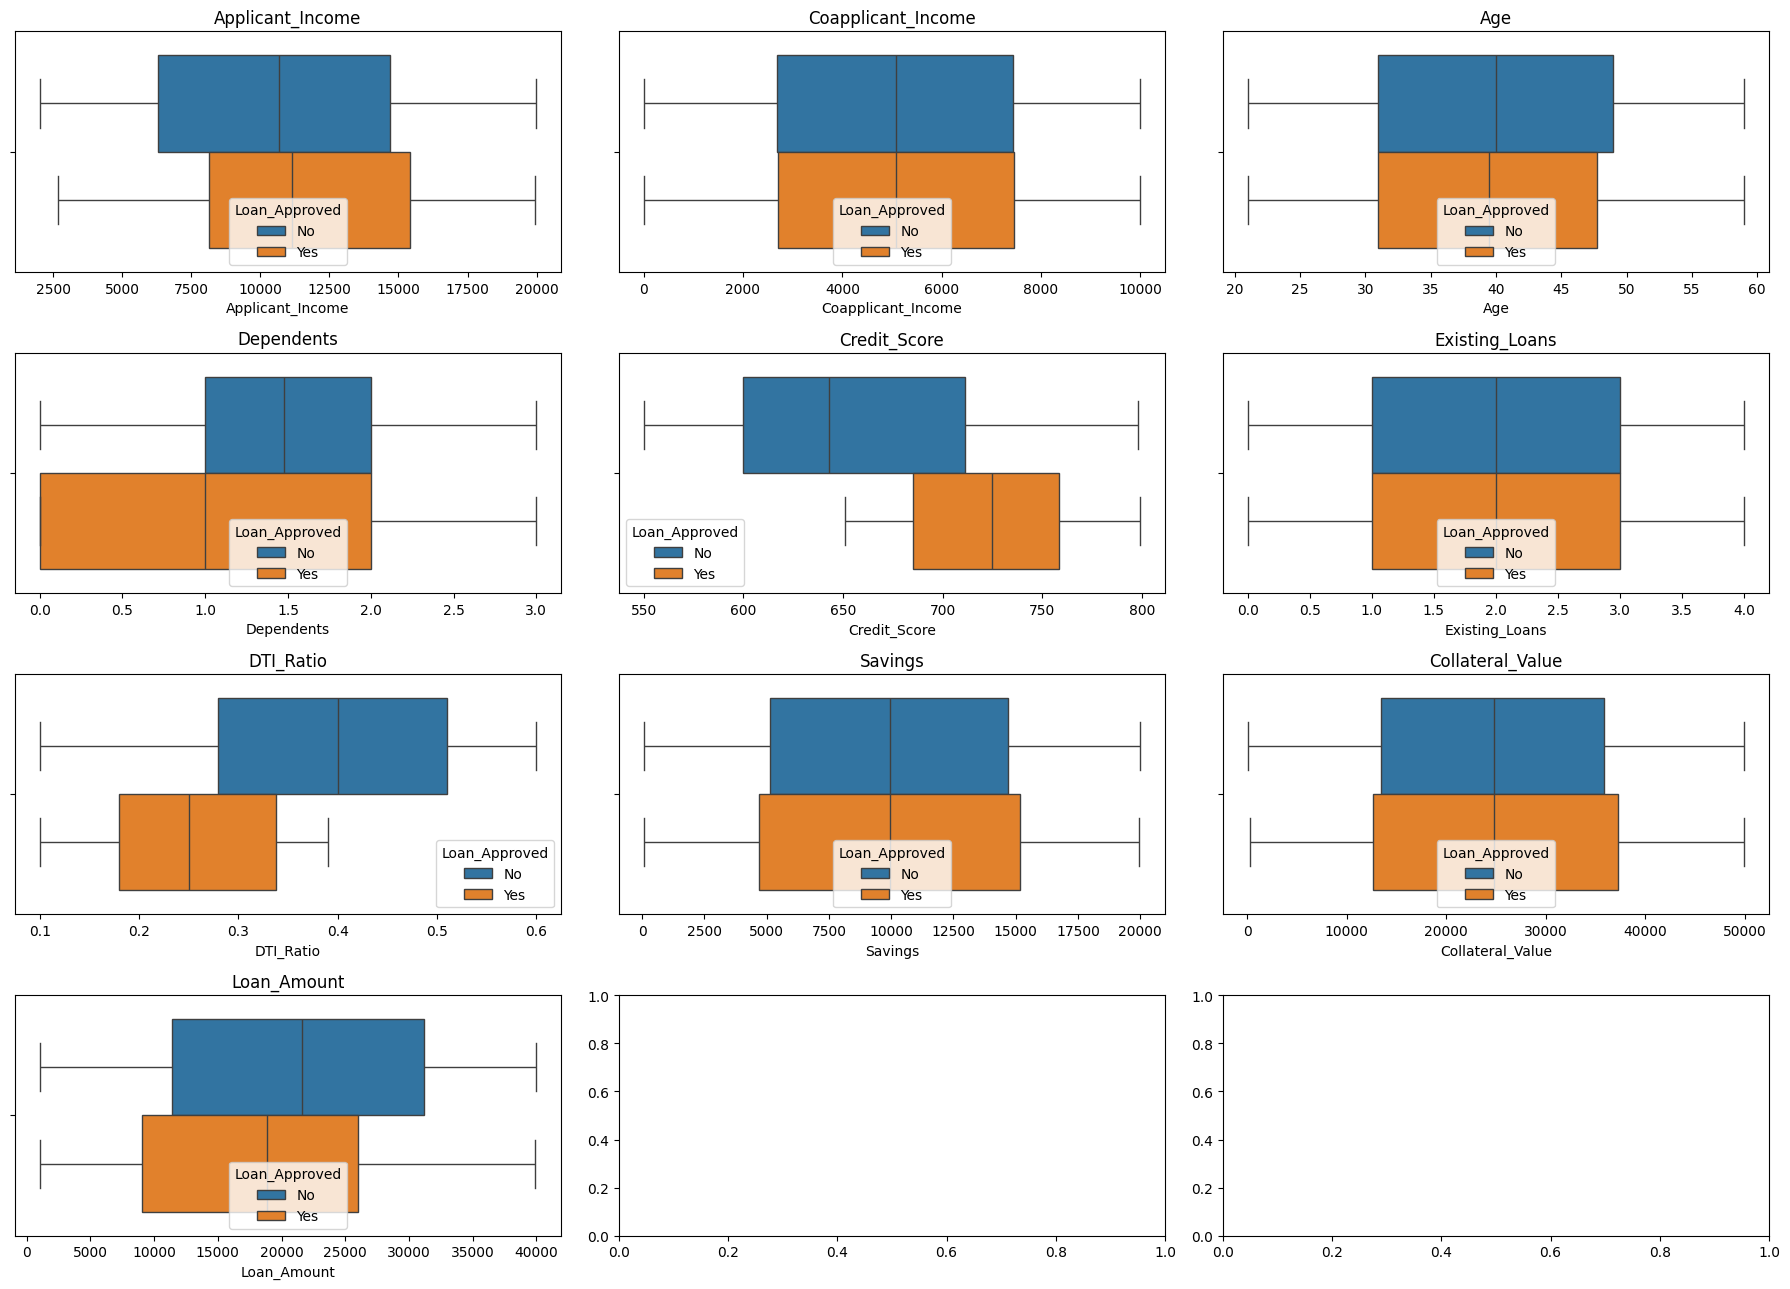

In [216]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize= (18,13))
axes = axes.flatten()

for i, col in enumerate(df_filled.columns[:10]):
    sns.boxplot(data = df_filled, x = col, ax = axes[i], fill = True, hue='Loan_Approved')
    axes[i].set_title(col)

plt.tight_layout()

# Key Insights
- no outliers are detected 
- overall feature distributions are fine  

In [204]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
categirical_columns = ['Employment_Status','Marital_Status', 'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender', 'Employer_Category']

encoded = ohe.fit_transform(df_filled[categirical_columns])

In [205]:
encoded_df = pd.DataFrame(encoded, columns= ohe.get_feature_names_out(categirical_columns), index=df_filled.index)
df_encoded = pd.concat([df_filled.drop(columns=categirical_columns), encoded_df], axis=1)

In [206]:
lbe = LabelEncoder()
df_encoded['Loan_Approved'] = lbe.fit_transform(df_encoded['Loan_Approved'])

In [207]:
df_encoded.head()
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Loan_Approved                    1000 non-null   int64  
 12  Employment_Status_Sal

## Correlation Heatmap

In [222]:
df_encoded.corr()['Loan_Approved'].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level_Not Graduate    

<Axes: >

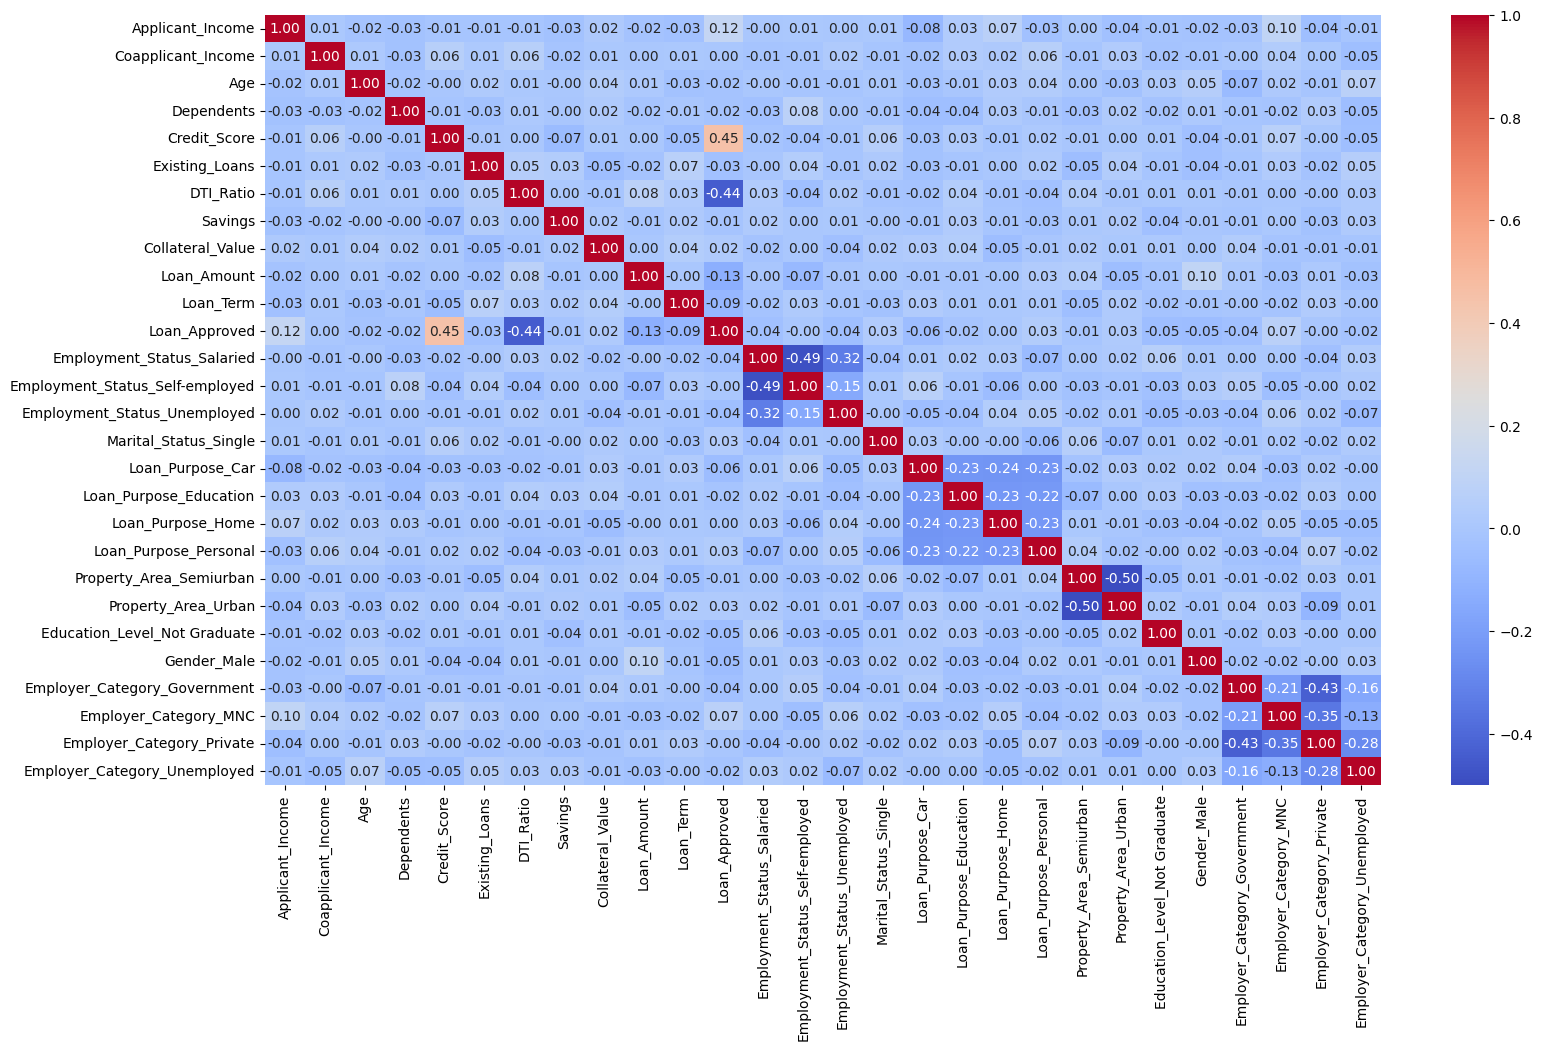

In [208]:
corr_matrix = df_encoded.corr()
plt.figure(figsize=(18,10))
sns.heatmap(
    corr_matrix,
    annot= True,
    fmt = '.2f',
    cmap= 'coolwarm'
)



## Model Training

In [233]:
X = df_encoded.drop(columns=['Loan_Approved'])
y = df_encoded['Loan_Approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [234]:
y_test

521    0
737    0
740    0
660    0
411    0
      ..
408    0
332    0
208    1
613    1
78     0
Name: Loan_Approved, Length: 200, dtype: int64

In [235]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [236]:
# LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_predict_lr = lr.predict(X_test_scaled)

print("precision_score", precision_score(y_test, y_predict_lr)) 
print('recall_score', recall_score(y_test, y_predict_lr))
print("accuracy_score", accuracy_score(y_test, y_predict_lr))
print("f1_score", f1_score(y_test, y_predict_lr)) 

precision_score 0.8135593220338984
recall_score 0.7868852459016393
accuracy_score 0.88
f1_score 0.8


In [237]:
#KNN Classifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_predict_knn = knn.predict(X_test_scaled)

print("precision_score", precision_score(y_test, y_predict_knn)) 
print('recall_score', recall_score(y_test, y_predict_knn))
print("accuracy_score", accuracy_score(y_test, y_predict_knn))
print("f1_score", f1_score(y_test, y_predict_knn)) 


precision_score 0.64
recall_score 0.5245901639344263
accuracy_score 0.765
f1_score 0.5765765765765766


In [238]:
#Naive Bayes

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_predict_gnb = gnb.predict(X_test_scaled)

print("precision_score", precision_score(y_test, y_predict_gnb)) 
print('recall_score', recall_score(y_test, y_predict_gnb))
print("accuracy_score", accuracy_score(y_test, y_predict_gnb))
print("f1_score", f1_score(y_test, y_predict_gnb)) 

precision_score 0.8431372549019608
recall_score 0.7049180327868853
accuracy_score 0.87
f1_score 0.7678571428571429
